In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [150]:
df = pd.read_csv("Car Sale.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB


In [151]:
#1 What is the average selling price of cars for each dealer, and how does it compare across different dealers?
df_dealer = df.groupby(["Dealer_No "])["Price ($)"].mean().round(2).reset_index(name  = "Avg_price_per_dealer")
df_dealer

,Dealer_No,Avg_price_per_dealer
0,06457-3834,27771.61
1,38701-8047,28208.62
2,53546-9427,28009.71
3,60504-7114,28134.03
4,78758-7841,28272.41
5,85257-3102,28259.14
6,99301-3882,27920.85


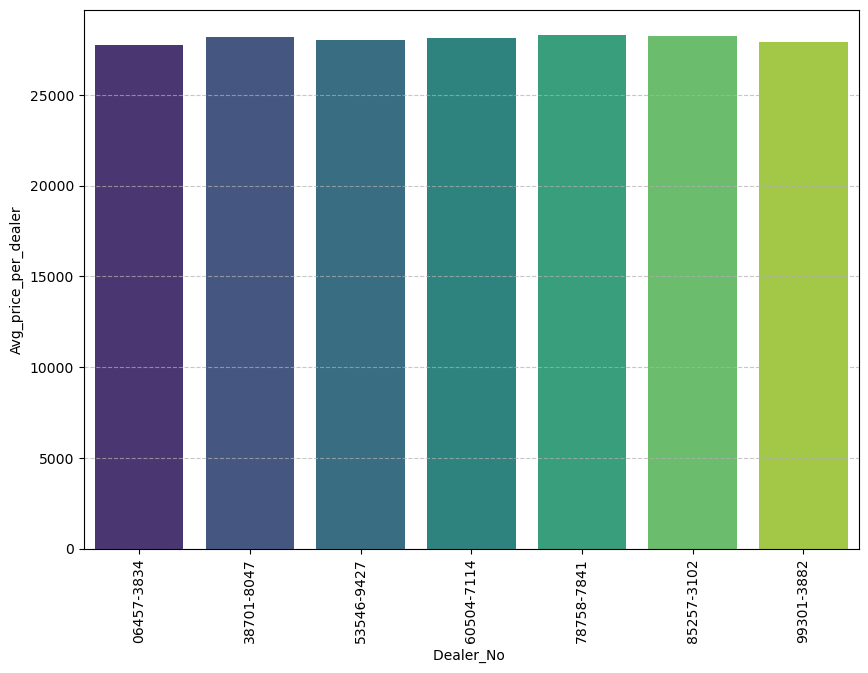

In [154]:
plt.figure(figsize=(10,7))
sns.barplot(x="Dealer_No ",y="Avg_price_per_dealer", data = df_dealer,palette = 'viridis')
plt.grid(axis = 'y',linestyle = '--',alpha=0.7)
plt.xticks(rotation =90)
plt.show()

In [155]:
#2 Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends?

In [158]:
df.groupby('Company')['Price ($)'].var().sort_values(ascending = False).head(5)

Company
Lincoln     3.864389e+08
Saab        3.862695e+08
Cadillac    3.809180e+08
Plymouth    3.635123e+08
Lexus       3.187269e+08
Name: Price ($), dtype: float64

In [160]:
# Highest variance brand → “This company has the widest range of prices, which suggests its pricing trends cover multiple market categories,
#from low-end to high-end.”


In [162]:
#3 What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare?
df.groupby("Transmission")['Price ($)'].describe()

,count,mean,std,min,25%,50%,75%,max
Transmission,,,,,,,,
Auto,12571.0,28248.525972,13747.070597,1200.0,19000.0,24000.0,35500.0,75700.0
Manual,11335.0,27914.710631,15862.871978,1700.0,17000.0,22001.0,34000.0,85800.0


In [164]:
df.groupby("Transmission")['Price ($)'].apply(lambda x : x.quantile(0.75)-x.quantile(0.25))

Transmission
Auto      16500.0
Manual    17000.0
Name: Price ($), dtype: float64

In [166]:
# Interpretation
# Both transmissions have very similar variability in the middle 50% of prices.
# Manual cars have a slightly wider spread, meaning their prices fluctuate a bit more.
# Auto cars are marginally more consistent in pricing.

In [168]:
#4 What is the distribution of car prices across different regions?
df.groupby("Dealer_Region")["Price ($)"].describe()

,count,mean,std,min,25%,50%,75%,max
Dealer_Region,,,,,,,,
Aurora,3130.0,28334.626837,15026.207252,9000.0,18001.0,23000.0,35000.0,85800.0
Austin,4135.0,28341.603628,14903.884549,9000.0,18001.0,23801.0,35001.0,85601.0
Greenville,3128.0,28180.819054,15101.538328,1200.0,18001.0,22500.0,34500.0,85200.0
Janesville,3821.0,27833.350955,14344.995638,4300.0,18001.0,23000.0,34000.0,85400.0
Middletown,3128.0,27856.338875,14619.842395,1700.0,18000.0,22750.0,34000.0,85300.0
Pasco,3131.0,28119.039923,14659.315941,9000.0,18500.5,23000.0,34000.0,85600.0
Scottsdale,3433.0,27954.958928,14902.916820,1450.0,18000.0,22600.0,33500.0,85001.0


In [170]:
df.groupby("Dealer_Region")["Price ($)"].apply(lambda x: x.quantile(0.75)-x.quantile(0.25))

Dealer_Region
Aurora        16999.0
Austin        17000.0
Greenville    16499.0
Janesville    15999.0
Middletown    16000.0
Pasco         15499.5
Scottsdale    15500.0
Name: Price ($), dtype: float64

In [172]:
#5 What is the distribution of cars based on body styles?
df['Body Style'].value_counts()

Body Style
SUV          6374
Hatchback    6128
Sedan        4488
Passenger    3945
Hardtop      2971
Name: count, dtype: int64

In [174]:
#6 How does the average selling price of cars vary by customer gender and annual income?
df.groupby('Gender')[['Annual Income','Price ($)']].mean()


,Annual Income,Price ($)
Gender,,
Female,755973.021339,28277.265270
Male,851184.044207,28039.429407


In [176]:
#7 What is the distribution of car prices by region, and how does the number of cars sold vary by region?
df.groupby("Dealer_Region")["Price ($)"].describe()


,count,mean,std,min,25%,50%,75%,max
Dealer_Region,,,,,,,,
Aurora,3130.0,28334.626837,15026.207252,9000.0,18001.0,23000.0,35000.0,85800.0
Austin,4135.0,28341.603628,14903.884549,9000.0,18001.0,23801.0,35001.0,85601.0
Greenville,3128.0,28180.819054,15101.538328,1200.0,18001.0,22500.0,34500.0,85200.0
Janesville,3821.0,27833.350955,14344.995638,4300.0,18001.0,23000.0,34000.0,85400.0
Middletown,3128.0,27856.338875,14619.842395,1700.0,18000.0,22750.0,34000.0,85300.0
Pasco,3131.0,28119.039923,14659.315941,9000.0,18500.5,23000.0,34000.0,85600.0
Scottsdale,3433.0,27954.958928,14902.916820,1450.0,18000.0,22600.0,33500.0,85001.0


In [178]:
df["Dealer_Region"].value_counts()


Dealer_Region
Austin        4135
Janesville    3821
Scottsdale    3433
Pasco         3131
Aurora        3130
Middletown    3128
Greenville    3128
Name: count, dtype: int64

In [180]:
#8 How does the average car price differ between cars with different engine sizes?
df.groupby("Engine")["Price ($)"].mean()

Engine
DoubleÂ Overhead Camshaft    28248.525972
Overhead Camshaft            27914.710631
Name: Price ($), dtype: float64

In [182]:
#9 How do car prices vary based on the customer’s annual income bracket?
bins = [0, 50000, 200000, 500000, 1000000, df['Annual Income'].max()]
labels = ['Low', 'Lower-Mid', 'Mid', 'Upper-Mid', 'High']

df['Income_Bracket'] = pd.cut(df['Annual Income'], bins=bins, labels=labels, include_lowest=True)

df.groupby('Income_Bracket')["Price ($)"].mean().round(2)


Income_Bracket
Low          27884.30
Lower-Mid    24094.06
Mid          28602.54
Upper-Mid    28011.73
High         28186.20
Name: Price ($), dtype: float64

In [202]:
#10 What are the top 5 car models with the highest number of sales, and how does their price distribution look?
top5_models = df['Model'].value_counts().head(5)
print(top5_models)

Model
Diamante      418
Silhouette    411
Prizm         411
Passat        391
Ram Pickup    383
Name: count, dtype: int64


In [206]:
df[df['Model'].isin(top5_models.index)].groupby('Model')['Price ($)'].describe()

,count,mean,std,min,25%,50%,75%,max
Model,,,,,,,,
Diamante,418.0,22268.303828,9770.768958,12000.0,18000.0,19001.0,22000.0,49801.0
Passat,391.0,19600.728900,8218.521683,9000.0,12001.0,20000.0,27001.0,32501.0
Prizm,411.0,22838.457421,8012.531045,15000.0,16000.0,22000.0,25000.0,44700.0
Ram Pickup,383.0,27820.864230,13297.609534,16000.0,19000.0,21000.0,39300.0,57750.0
Silhouette,411.0,29858.513382,17940.571762,12000.0,14001.0,25000.0,34500.0,60750.0


In [222]:
#11 How does car price vary with engine size across different car colors, and which colors have the highest price variation?
df.groupby(['Color','Engine'])['Price ($)'].var()

Color       Engine                   
Black       DoubleÂ Overhead Camshaft    1.542235e+08
            Overhead Camshaft            3.047610e+08
Pale White  DoubleÂ Overhead Camshaft    2.074295e+08
            Overhead Camshaft            1.690027e+08
Red         DoubleÂ Overhead Camshaft    1.822326e+08
            Overhead Camshaft            3.009060e+08
Name: Price ($), dtype: float64

In [ ]:
# Price variation by engine across colors:
# Overhead Camshaft engines generally have higher price variance than Double Overhead Camshaft.
# Colors with highest variation:
# Black and Red cars with Overhead Camshaft engines show the most price fluctuation.
# Insight:
# If a customer is buying a Black or Red car with Overhead Camshaft, prices vary a lot → may depend on model, trim, or dealer.
# Pale White cars are slightly more consistent in pricing.

In [226]:
#12 Is there any seasonal trend in car sales based on the date of sale?
df.Date.dtype

dtype('O')

In [234]:
df["Date"] = pd.to_datetime(df["Date"])

In [242]:
df["Month"] = df["Date"].dt.month

In [247]:
monthly_sales = df['Month'].value_counts().sort_index()
print(monthly_sales)


Month
1      790
2      735
3     1535
4     1655
5     1895
6     1715
7     1725
8     1705
9     3305
10    1830
11    3470
12    3546
Name: count, dtype: int64


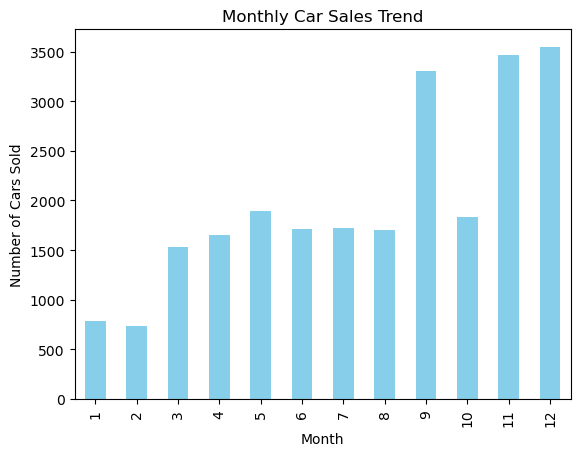

In [249]:
monthly_sales.plot(kind='bar', color='skyblue')
plt.xlabel('Month')
plt.ylabel('Number of Cars Sold')
plt.title('Monthly Car Sales Trend')
plt.show()


In [255]:
# Insigt = Maximum sale is in December

In [259]:
#13 How does the car price distribution change when considering different combinations of body style and transmission type?
df.groupby(['Body Style','Transmission'])['Price ($)'].mean()

Body Style  Transmission
Hardtop     Auto            31520.188210
            Manual          27016.943698
Hatchback   Auto            25910.544824
            Manual          28702.550562
Passenger   Auto            28915.835149
            Manual          28969.521039
SUV         Auto            27501.404407
            Manual          26079.019161
Sedan       Auto            29955.294344
            Manual          29664.271572
Name: Price ($), dtype: float64

In [282]:
#14 What is the correlation between car price, engine size, and annual income of customers, and how do these features interact?
col = df[['Price ($)','Annual Income']]
col.corr()

#there is no column is given in dataset with engine size

,Price ($),Annual Income
Price ($),1.000000,0.012065
Annual Income,0.012065,1.000000


In [289]:
#15 How does the average car price vary across different car models and engine types?
avg_prices = df.groupby(['Model','Engine'])['Price ($)'].mean().unstack()
print(avg_prices)


Engine    DoubleÂ Overhead Camshaft  Overhead Camshaft
Model                                                 
3-Sep                  37986.380117                NaN
3000GT                 22764.326923       21770.659864
300M                   21394.888889                NaN
323i                   16744.632287       21038.162162
328i                   21069.149606       38676.177215
...                             ...                ...
Viper                  32118.479167       26052.375000
Voyager                22066.026316       33995.678322
Windstar               25145.636364       17100.272727
Wrangler               21145.294737       18742.942029
Xterra                 15940.459459       31072.500000

[154 rows x 2 columns]
